# 🏠 Hedonic Pricing Model: Многофакторный анализ цены за м² на рынке новостроек

## Цель исследования
1. Выявить факторы, влияющие на цену квадратного метра квартиры
2. Построить модель линейной регрессии с проверкой всех предпосылок
3. **Проверить гипотезу**: студии и однокомнатные квартиры стоят дороже за м²

## Методология
- **Hedonic Pricing Model** (Rosen, 1974) — декомпозиция цены на вклад отдельных характеристик
- **Стандартизация признаков** (Z-score) для сравнимости коэффициентов
- **Робастные стандартные ошибки** (HC3) при наличии гетероскедастичности

---

## 1. Загрузка библиотек

In [1]:
# Основные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Статистика и регрессия
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats
from scipy.stats import shapiro
from sklearn.preprocessing import StandardScaler

# Настройки визуализации
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')

print("✓ Библиотеки загружены")

✓ Библиотеки загружены


## 2. Загрузка и первичный осмотр данных

In [2]:
# Загрузка данных
deals = pd.read_csv('clear_deals.csv')
projects = pd.read_csv('clear_projects.csv')

print(f"Сделки: {deals.shape[0]:,} записей, {deals.shape[1]} столбцов")
print(f"Проекты: {projects.shape[0]:,} записей, {projects.shape[1]} столбцов")

# Объединение датасетов
df = deals.merge(
    projects.drop_duplicates(subset="id_корпуса", keep="first")[
        ["id_корпуса", "проект", "класс_проекта", "девелопер", 
         "конструкция_дома", "этажей_от", "этажей_до", 
         "плановая_дата_рвэ", "стадия_строительства"]
    ],
    on="id_корпуса",
    how="left"
)

print(f"\nОбъединённый датасет: {df.shape[0]:,} записей, {df.shape[1]} столбцов")
df.head()

Сделки: 50,955 записей, 31 столбцов
Проекты: 21,273 записей, 16 столбцов

Объединённый датасет: 50,955 записей, 39 столбцов


,название_региона,город,округ,район,класс,конструкция_объекта,застройщик,название_жк,адрес_корпуса,id_корпуса,...,ипц,реальная_сумма_бюджета,проект,класс_проекта,девелопер,конструкция_дома,этажей_от,этажей_до,плановая_дата_рвэ,стадия_строительства
0,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,116.6560,1.133937e+07,Прокшино,Комфорт,А101,Монолит-блоки,7.0,16.0,2025-12-31,Монтажные и отделочные работы
1,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,112.6680,1.154491e+07,Прокшино,Комфорт,А101,Монолит-блоки,7.0,16.0,2025-12-31,Монтажные и отделочные работы
2,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,115.1362,1.558428e+07,Прокшино,Комфорт,А101,Монолит-блоки,7.0,16.0,2025-12-31,Монтажные и отделочные работы
3,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,116.6560,1.481381e+07,Прокшино,Комфорт,А101,Монолит-блоки,7.0,16.0,2025-12-31,Монтажные и отделочные работы
4,Новая Москва,дер. Николо-Хованское,НАО,Коммунарка,Комфорт,Монолит-блоки,А101,Прокшино,"Сосенское пос., кв-л 26, з/у 3/3, к. 10.1.5",002b4f20e97d6ca8ac349b5e2e9e81d3,...,112.6680,1.536217e+07,Прокшино,Комфорт,А101,Монолит-блоки,7.0,16.0,2025-12-31,Монтажные и отделочные работы


In [49]:
deals["тип_лота"].value_counts()

тип_лота
квартира       49900
апартаменты     1055
Name: count, dtype: int64

In [50]:
deals["суммарное_количество_сделок"]

0        1
1        1
2        1
3        1
4        1
        ..
50950    1
50951    1
50952    1
50953    1
50954    1
Name: суммарное_количество_сделок, Length: 50955, dtype: int64

In [3]:
# Информация о данных
print("\n" + "="*60)
print("СТРУКТУРА ДАННЫХ")
print("="*60)
print(f"\nУникальные значения комнатности: {df['количество_комнат'].unique()}")
print(f"Уникальные классы: {df['класс'].unique()}")
print(f"Уникальные районы: {df['район'].unique()}")
print(f"Диапазон цен: {df['сумма_бюджета'].min()/1e6:.1f} - {df['сумма_бюджета'].max()/1e6:.1f} млн ₽")
print(f"Диапазон площадей: {df['суммарная_площадь_сделок'].min():.0f} - {df['суммарная_площадь_сделок'].max():.0f} м²")


СТРУКТУРА ДАННЫХ

Уникальные значения комнатности: ['1' '2' '3' 'ст' '4']
Уникальные классы: ['Комфорт' 'Бизнес-' 'Эконом' 'Бизнес']
Уникальные районы: ['Коммунарка' 'Внуково' 'Троицк' 'Щербинка' 'Филимонковский']
Диапазон цен: 2.1 - 203.1 млн ₽
Диапазон площадей: 14 - 715 м²


---
## 3. Обоснование выбора факторов для модели

На основе исследований hedonic pricing (Rosen 1974, ЦИАН, Домклик, IRN) выделяем следующие группы факторов:

### 3.1 Структурные характеристики объекта

| Фактор | Обоснование | Ожидаемый эффект |
|--------|-------------|------------------|
| **Площадь** | Основной ценообразующий фактор. Эффект масштаба: чем больше площадь, тем ниже цена за м² | Отрицательный |
| **Комнатность** | Студии и 1к дороже за м² из-за инвестиционной привлекательности и низкого порога входа | Студии/1к = премия |
| **Этаж** | 1 этаж — дисконт 10-15% (шум, безопасность), верхние — премия за вид | Положительный |
| **Относительный этаж** | Позиция в доме (0-1) — нормализованный показатель | Положительный |

### 3.2 Характеристики проекта

| Фактор | Обоснование | Ожидаемый эффект |
|--------|-------------|------------------|
| **Класс жилья** | Ключевой фактор: Эконом < Комфорт < Бизнес. Разница до 50% | Бизнес = премия |
| **Стадия строительства** | Котлован дешевле на 15-25%, готовый дом — премия | Готовый = премия |
| **Тип отделки** | С отделкой дороже на 10-20% | С отделкой = премия |
| **Застройщик** | Репутация застройщика влияет на цену (А101, ПИК vs мелкие) | Топ = премия |

### 3.3 Локационные факторы

| Фактор | Обоснование | Ожидаемый эффект |
|--------|-------------|------------------|
| **Район** | Близость к МКАД, инфраструктура, транспорт | Коммунарка = премия |

### 3.4 Характеристики сделки

| Фактор | Обоснование | Ожидаемый эффект |
|--------|-------------|------------------|
| **Тип договора** | Уступка vs ДДУ — маржа инвестора 5-15% | Неоднозначный |
| **Ипотека** | Ипотечники могут платить больше (субсидирование) | Слабый положительный |
| **Временной тренд** | Динамика рынка, инфляция | Контроль |

---

## 4. Feature Engineering

In [4]:
# === ЦЕЛЕВАЯ ПЕРЕМЕННАЯ ===
# Цена за м² с учётом инфляции (реальная цена)
df['цена_за_кв_м'] = df['реальная_сумма_бюджета'] / df['суммарная_площадь_сделок']

print(f"Цена за м²:")
print(f"  Среднее: {df['цена_за_кв_м'].mean():,.0f} ₽")
print(f"  Медиана: {df['цена_за_кв_м'].median():,.0f} ₽")
print(f"  Мин-Макс: {df['цена_за_кв_м'].min():,.0f} - {df['цена_за_кв_м'].max():,.0f} ₽")

Цена за м²:
  Среднее: 228,874 ₽
  Медиана: 223,565 ₽
  Мин-Макс: 52,983 - 508,130 ₽


In [5]:
# === КОМНАТНОСТЬ (категориальная) ===
def normalize_rooms(value):
    """Нормализация значений комнатности"""
    value = str(value).strip().lower()
    mapping = {
        'ст': 'Студия', 'студия': 'Студия', '0': 'Студия',
        '1': '1-комн', '2': '2-комн', '3': '3-комн', 
        '4': '4-комн', '5': '5+ комн', '6': '5+ комн'
    }
    return mapping.get(value, 'Другое')

df['тип_квартиры'] = df['количество_комнат'].astype(str).str.strip().str.lower().apply(normalize_rooms)

# Бинарный признак: малый формат (студия или 1к)
df['малый_формат'] = df['тип_квартиры'].isin(['Студия', '1-комн']).astype(int)

print("Распределение по типам квартир:")
print(df['тип_квартиры'].value_counts())
print(f"\nДоля малого формата: {df['малый_формат'].mean()*100:.1f}%")

Распределение по типам квартир:
тип_квартиры
1-комн    20475
2-комн    14095
Студия     9565
3-комн     6316
4-комн      504
Name: count, dtype: int64

Доля малого формата: 59.0%


In [ ]:
# === КЛАСС ЖИЛЬЯ ===
df['класс_жилья'] = df['класс'].fillna(df['класс_проекта']).fillna('Комфорт')
# df['класс_жилья'] = df['класс_жилья'].replace({'Бизнес-': 'Бизнес'})

print("Распределение по классам:")
print(df['класс_жилья'].value_counts())

Распределение по классам:
класс_жилья
Комфорт    48908
Эконом      1024
Бизнес      1023
Name: count, dtype: int64


In [7]:
# === ЭТАЖ ===
df['этаж_лота'] = pd.to_numeric(df['этаж_лота'], errors='coerce')
df['этажей_до'] = pd.to_numeric(df['этажей_до'], errors='coerce')

# Относительный этаж (позиция в доме 0-1)
df['относительный_этаж'] = df['этаж_лота'] / df['этажей_до']

# Флаг первого этажа
df['первый_этаж'] = (df['этаж_лота'] == 1).astype(int)

# Флаг последнего этажа
df['последний_этаж'] = (df['этаж_лота'] == df['этажей_до']).astype(int)

print(f"Этаж: {df['этаж_лота'].min():.0f} - {df['этаж_лота'].max():.0f}")
print(f"Доля первых этажей: {df['первый_этаж'].mean()*100:.1f}%")
print(f"Доля последних этажей: {df['последний_этаж'].mean()*100:.1f}%")

Этаж: 1 - 30
Доля первых этажей: 1.2%
Доля последних этажей: 4.7%


In [8]:
# === СТАДИЯ СТРОИТЕЛЬСТВА ===
stage_mapping = {
    'Строительство не начато': 'Котлован',
    'Работы нулевого цикла': 'Котлован',
    'Начало монтажных работ': 'Строительство',
    'Монтажные и отделочные работы': 'Строительство',
    'Получение РВЭ, благоустройство территории': 'Почти готов',
    'Введен в эксплуатацию': 'Сдан'
}
df['стадия'] = df['текущая_стадия_строительства'].map(stage_mapping).fillna('Строительство')

# Флаг готового дома
df['дом_сдан'] = (df['стадия'] == 'Сдан').astype(int)

print("Распределение по стадиям:")
print(df['стадия'].value_counts())

Распределение по стадиям:
стадия
Строительство    35036
Котлован         14746
Сдан               993
Почти готов        180
Name: count, dtype: int64


In [9]:
# === ТИП ОТДЕЛКИ ===
def simplify_otdelka(x):
    if pd.isna(x):
        return 'Без отделки'
    x = str(x).lower()
    if 'с отделкой' in x and 'без' not in x:
        return 'С отделкой'
    elif 'под чистовую' in x:
        return 'Под чистовую'
    elif 'мебел' in x:
        return 'С мебелью'
    else:
        return 'Без отделки'

df['тип_отделки'] = df['внутренняя_отделка'].apply(simplify_otdelka)

# Флаг наличия отделки
df['есть_отделка'] = df['тип_отделки'].isin(['С отделкой', 'С мебелью', 'Под чистовую']).astype(int)

print("Распределение по отделке:")
print(df['тип_отделки'].value_counts())

Распределение по отделке:
тип_отделки
С отделкой      23584
Без отделки     17253
Под чистовую     7398
С мебелью        2720
Name: count, dtype: int64


In [10]:
# === ХАРАКТЕРИСТИКИ СДЕЛКИ ===
df['уступка'] = (df['уступка'] == 'Договор уступки').astype(int)
df['ипотека'] = (df['ипотека'] == 'Ипотека').astype(int)
df['покупатель_юл'] = (df['покупатель'] == 'ЮЛ').astype(int)

print(f"Доля уступок: {df['уступка'].mean()*100:.1f}%")
print(f"Доля ипотеки: {df['ипотека'].mean()*100:.1f}%")
print(f"Доля покупателей-ЮЛ: {df['покупатель_юл'].mean()*100:.1f}%")

Доля уступок: 2.9%
Доля ипотеки: 81.2%
Доля покупателей-ЮЛ: 1.4%


In [11]:
# === ВРЕМЕННЫЕ ПРИЗНАКИ ===
df['месяц_дата'] = pd.to_datetime(df['месяц'], errors='coerce')
df['год'] = df['месяц_дата'].dt.year
df['месяц_года'] = df['месяц_дата'].dt.month
df['квартал'] = df['месяц_дата'].dt.quarter

# Числовой месяц для тренда (месяцы от начала периода)
min_date = df['месяц_дата'].min()
df['месяц_номер'] = ((df['месяц_дата'].dt.year - min_date.year) * 12 + 
                     (df['месяц_дата'].dt.month - min_date.month))

print(f"Период данных: {df['месяц_дата'].min()} - {df['месяц_дата'].max()}")
print(f"Месяцев в периоде: {df['месяц_номер'].max() + 1}")

Период данных: 2023-01-01 00:00:00 - 2024-12-01 00:00:00
Месяцев в периоде: 24


In [12]:
# === ЗАСТРОЙЩИК (топ-5 + другие) ===
top_developers = df['застройщик'].value_counts().head(5).index.tolist()
df['застройщик_топ'] = df['застройщик'].apply(lambda x: x if x in top_developers else 'Другие')

print("Топ застройщиков:")
print(df['застройщик_топ'].value_counts())

Топ застройщиков:
застройщик_топ
А101                    19146
Самолет                 15869
ПИК                      5937
Другие                   4124
Абсолют Недвижимость     3111
РОСТ                     2768
Name: count, dtype: int64


In [13]:
# === ФИНАЛЬНАЯ ПОДГОТОВКА ДАННЫХ ===
# Удаляем пропуски в ключевых переменных
required_cols = ['цена_за_кв_м', 'суммарная_площадь_сделок', 'этаж_лота', 
                 'тип_квартиры', 'класс_жилья', 'район']

df_model = df.dropna(subset=required_cols).copy()
print(f"Записей для модели: {len(df_model):,} (из {len(df):,})")

# Удаляем выбросы по цене (за пределами 1-99 перцентилей)
q01, q99 = df_model['цена_за_кв_м'].quantile([0.01, 0.99])
df_model = df_model[(df_model['цена_за_кв_м'] >= q01) & (df_model['цена_за_кв_м'] <= q99)]
print(f"После удаления выбросов: {len(df_model):,}")

Записей для модели: 50,119 (из 50,955)
После удаления выбросов: 49,115


---
## 5. Exploratory Data Analysis (EDA)

In [14]:
# Описательная статистика
print("="*60)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*60)

stats_summary = df_model[['цена_за_кв_м', 'суммарная_площадь_сделок', 'этаж_лота', 
                          'реальная_сумма_бюджета']].describe()
stats_summary.loc['mean', 'реальная_сумма_бюджета'] /= 1e6
stats_summary.loc['std', 'реальная_сумма_бюджета'] /= 1e6
stats_summary.loc['min', 'реальная_сумма_бюджета'] /= 1e6
stats_summary.loc['max', 'реальная_сумма_бюджета'] /= 1e6
stats_summary.columns = ['Цена за м² (₽)', 'Площадь (м²)', 'Этаж', 'Бюджет (млн ₽)']
print(stats_summary.round(1))

ОПИСАТЕЛЬНАЯ СТАТИСТИКА
       Цена за м² (₽)  Площадь (м²)     Этаж  Бюджет (млн ₽)
count         49115.0       49115.0  49115.0         49115.0
mean         228563.2          46.7      8.0            10.3
std           41059.8          19.3      4.5             3.8
min          142304.7          14.4      1.0             3.3
25%          198982.9          34.1      4.0       7609243.3
50%          223564.8          40.8      8.0       9629149.3
75%          253163.8          59.0     11.0      12423830.8
max          350760.1         715.1     30.0           186.1


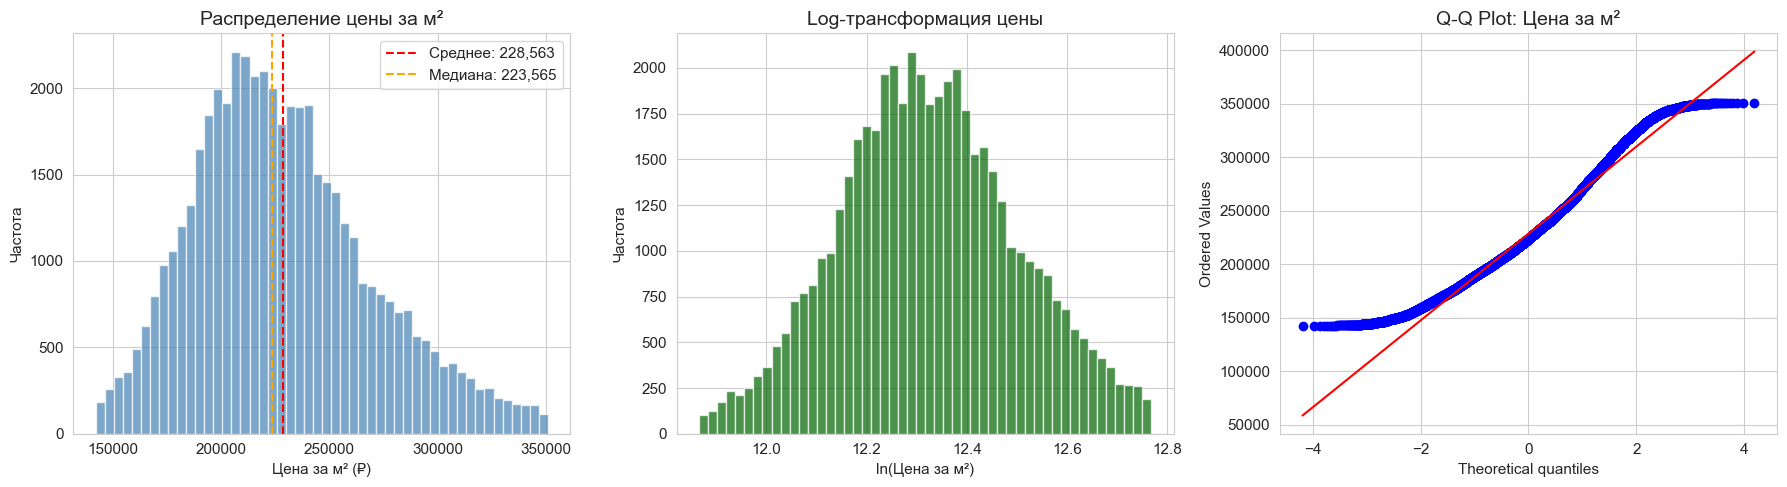

✓ Сохранено: 01_price_distribution.png


In [15]:
# График 1: Распределение целевой переменной
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма цены
axes[0].hist(df_model['цена_за_кв_м'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(df_model['цена_за_кв_м'].mean(), color='red', linestyle='--', label=f'Среднее: {df_model["цена_за_кв_м"].mean():,.0f}')
axes[0].axvline(df_model['цена_за_кв_м'].median(), color='orange', linestyle='--', label=f'Медиана: {df_model["цена_за_кв_м"].median():,.0f}')
axes[0].set_xlabel('Цена за м² (₽)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цены за м²')
axes[0].legend()

# Log-трансформация
axes[1].hist(np.log(df_model['цена_за_кв_м']), bins=50, color='darkgreen', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('ln(Цена за м²)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Log-трансформация цены')

# Q-Q plot для проверки нормальности
stats.probplot(df_model['цена_за_кв_м'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot: Цена за м²')

plt.tight_layout()
plt.savefig('01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Сохранено: 01_price_distribution.png")

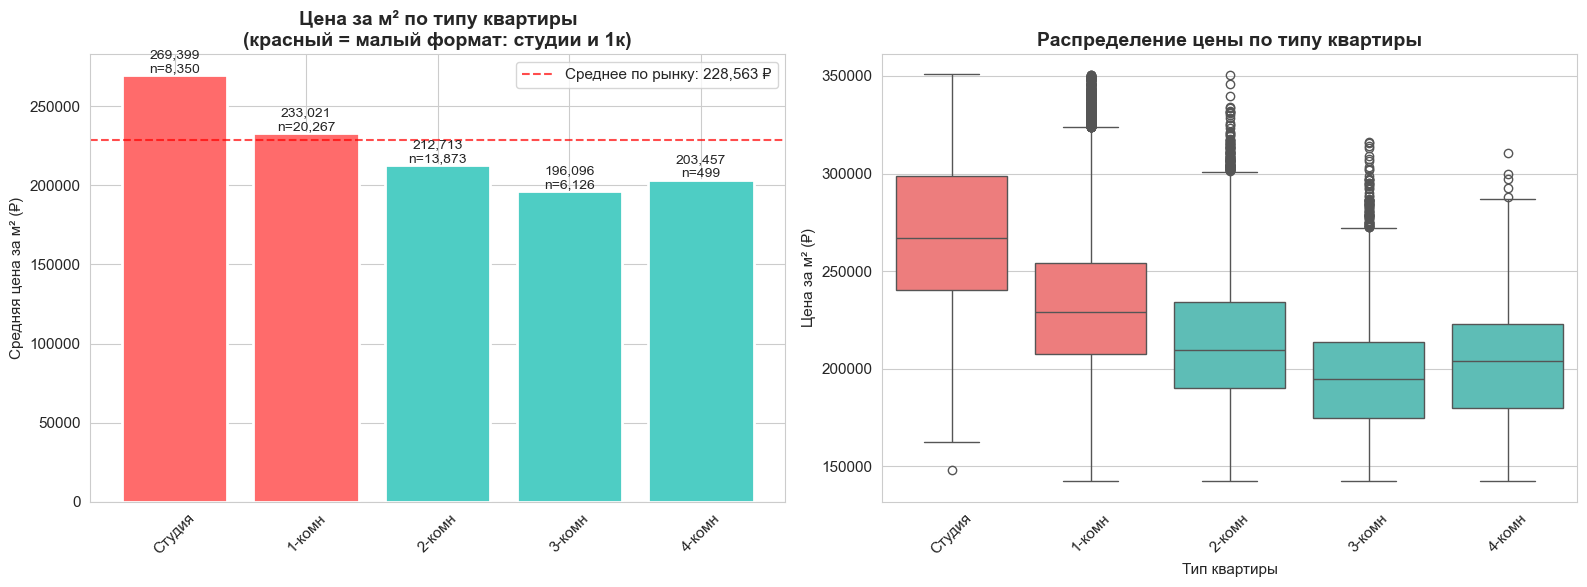


АНАЛИЗ ГИПОТЕЗЫ: Студии и 1к дороже за м²
Студия: 269,399 ₽/м² (+17.9% к среднему)
1-комн: 233,021 ₽/м² (+2.0% к среднему)
2-комн: 212,713 ₽/м² (-6.9% к среднему)
3-комн: 196,096 ₽/м² (-14.2% к среднему)
4-комн: 203,457 ₽/м² (-11.0% к среднему)


In [16]:
# График 2: Цена по типу квартиры (КЛЮЧЕВАЯ ГИПОТЕЗА)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

room_order = ['Студия', '1-комн', '2-комн', '3-комн', '4-комн']
room_prices = df_model.groupby('тип_квартиры')['цена_за_кв_м'].agg(['mean', 'median', 'std', 'count'])
room_prices = room_prices.reindex([r for r in room_order if r in room_prices.index])

# Bar chart
colors = ['#FF6B6B' if r in ['Студия', '1-комн'] else '#4ECDC4' for r in room_prices.index]
bars = axes[0].bar(room_prices.index, room_prices['mean'], color=colors, edgecolor='white', linewidth=2)
axes[0].axhline(y=df_model['цена_за_кв_м'].mean(), color='red', linestyle='--', alpha=0.7,
               label=f'Среднее по рынку: {df_model["цена_за_кв_м"].mean():,.0f} ₽')

for bar, (idx, row) in zip(bars, room_prices.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'{row["mean"]:,.0f}\nn={row["count"]:,.0f}', ha='center', fontsize=10)

axes[0].set_ylabel('Средняя цена за м² (₽)')
axes[0].set_title('Цена за м² по типу квартиры\n(красный = малый формат: студии и 1к)', fontweight='bold')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Box plot
df_plot = df_model[df_model['тип_квартиры'].isin(room_order)]
sns.boxplot(data=df_plot, x='тип_квартиры', y='цена_за_кв_м', order=room_order,
           palette=['#FF6B6B', '#FF6B6B', '#4ECDC4', '#4ECDC4', '#4ECDC4'], ax=axes[1])
axes[1].set_xlabel('Тип квартиры')
axes[1].set_ylabel('Цена за м² (₽)')
axes[1].set_title('Распределение цены по типу квартиры', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('02_price_by_room_type.png', dpi=150, bbox_inches='tight')
plt.show()

# Расчёт премии
print("\n" + "="*60)
print("АНАЛИЗ ГИПОТЕЗЫ: Студии и 1к дороже за м²")
print("="*60)
avg_price = df_model['цена_за_кв_м'].mean()
for room_type in room_order:
    if room_type in room_prices.index:
        price = room_prices.loc[room_type, 'mean']
        premium = ((price - avg_price) / avg_price) * 100
        print(f"{room_type}: {price:,.0f} ₽/м² ({premium:+.1f}% к среднему)")

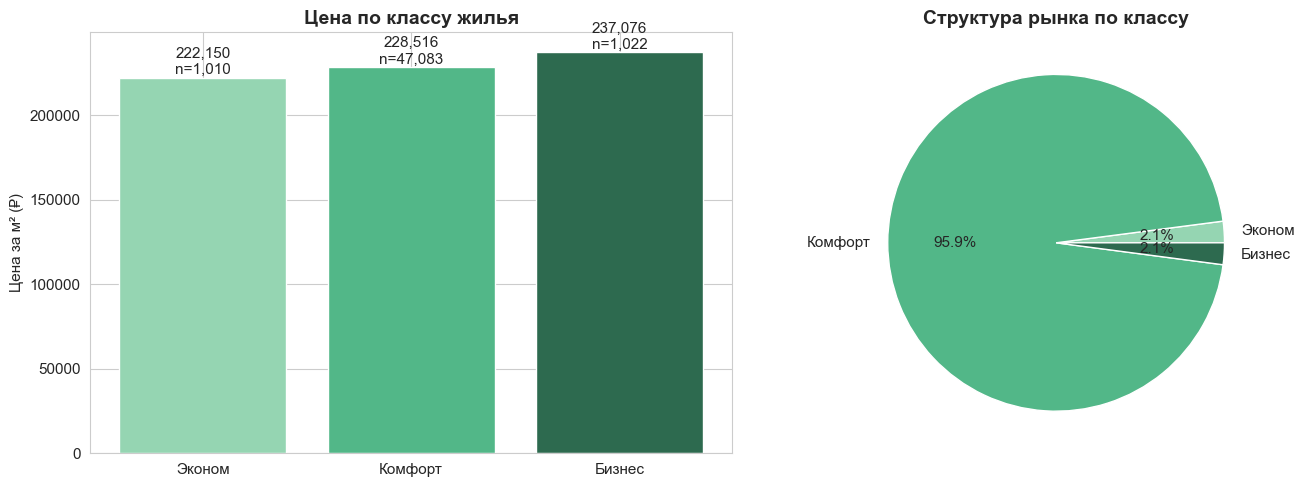

In [17]:
# График 3: Цена по классу жилья
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = ['Эконом', 'Комфорт', 'Бизнес']
class_prices = df_model.groupby('класс_жилья')['цена_за_кв_м'].agg(['mean', 'count'])
class_prices = class_prices.reindex([c for c in class_order if c in class_prices.index])

bars = axes[0].bar(class_prices.index, class_prices['mean'], 
                  color=['#95D5B2', '#52B788', '#2D6A4F'], edgecolor='white')
for bar, (idx, row) in zip(bars, class_prices.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'{row["mean"]:,.0f}\nn={row["count"]:,.0f}', ha='center', fontsize=11)
axes[0].set_ylabel('Цена за м² (₽)')
axes[0].set_title('Цена по классу жилья', fontweight='bold')

# Pie chart
axes[1].pie(class_prices['count'], labels=class_prices.index, autopct='%1.1f%%',
           colors=['#95D5B2', '#52B788', '#2D6A4F'])
axes[1].set_title('Структура рынка по классу', fontweight='bold')

plt.tight_layout()
plt.savefig('03_price_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

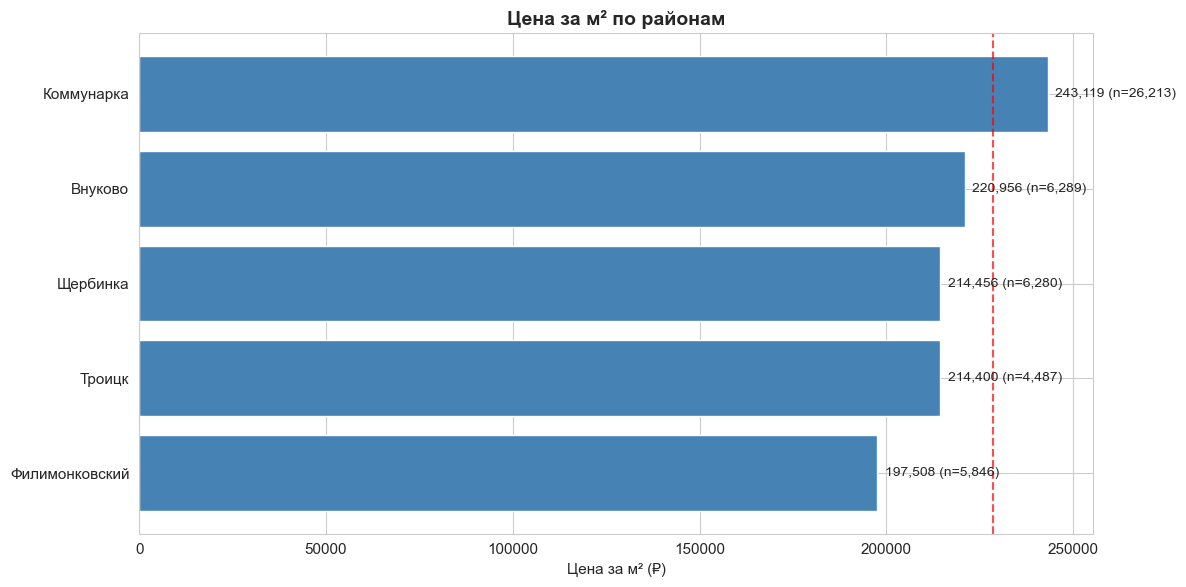

In [18]:
# График 4: Цена по районам
fig, ax = plt.subplots(figsize=(12, 6))

district_prices = df_model.groupby('район')['цена_за_кв_м'].agg(['mean', 'count']).sort_values('mean', ascending=True)

bars = ax.barh(district_prices.index, district_prices['mean'], color='steelblue', edgecolor='white')
for bar, (idx, row) in zip(bars, district_prices.iterrows()):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
           f'{row["mean"]:,.0f} (n={row["count"]:,.0f})', va='center', fontsize=10)
ax.set_xlabel('Цена за м² (₽)')
ax.set_title('Цена за м² по районам', fontweight='bold')
ax.axvline(df_model['цена_за_кв_м'].mean(), color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('04_price_by_district.png', dpi=150, bbox_inches='tight')
plt.show()

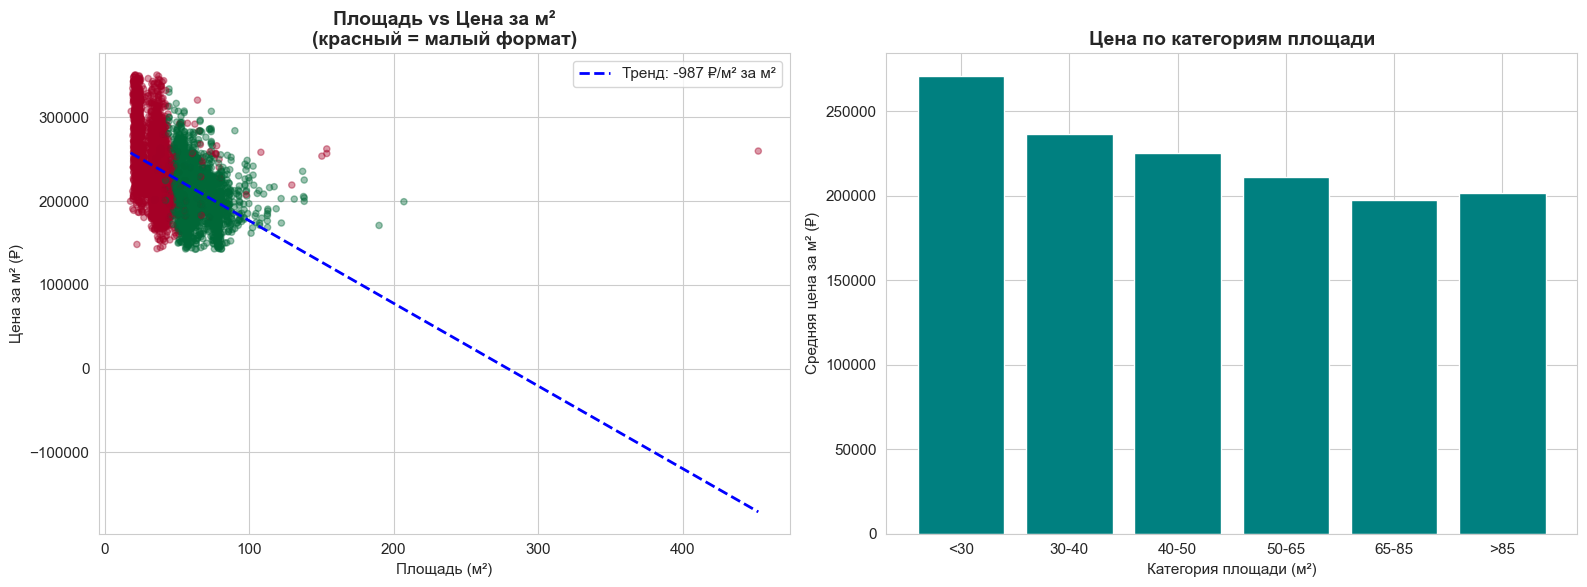


Корреляция площади и цены за м²: r = -0.493
Интерпретация: чем больше площадь, тем НИЖЕ цена за м² (эффект масштаба)


In [19]:
# График 5: Зависимость цены от площади
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
sample = df_model.sample(min(5000, len(df_model)), random_state=42)
scatter = axes[0].scatter(sample['суммарная_площадь_сделок'], sample['цена_за_кв_м'],
                         c=sample['малый_формат'], cmap='RdYlGn_r', alpha=0.4, s=20)
axes[0].set_xlabel('Площадь (м²)')
axes[0].set_ylabel('Цена за м² (₽)')
axes[0].set_title('Площадь vs Цена за м²\n(красный = малый формат)', fontweight='bold')

# Линия тренда
z = np.polyfit(sample['суммарная_площадь_сделок'], sample['цена_за_кв_м'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['суммарная_площадь_сделок'].min(), 
                     sample['суммарная_площадь_сделок'].max(), 100)
axes[0].plot(x_line, p(x_line), 'b--', linewidth=2, label=f'Тренд: {z[0]:+.0f} ₽/м² за м²')
axes[0].legend()

# Binned analysis
df_model['площадь_бин'] = pd.cut(df_model['суммарная_площадь_сделок'], 
                                 bins=[0, 30, 40, 50, 65, 85, 200],
                                 labels=['<30', '30-40', '40-50', '50-65', '65-85', '>85'])
binned = df_model.groupby('площадь_бин')['цена_за_кв_м'].mean()
axes[1].bar(binned.index, binned.values, color='teal', edgecolor='white')
axes[1].set_xlabel('Категория площади (м²)')
axes[1].set_ylabel('Средняя цена за м² (₽)')
axes[1].set_title('Цена по категориям площади', fontweight='bold')

plt.tight_layout()
plt.savefig('05_price_vs_area.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляция
corr = df_model['суммарная_площадь_сделок'].corr(df_model['цена_за_кв_м'])
print(f"\nКорреляция площади и цены за м²: r = {corr:.3f}")
print("Интерпретация: чем больше площадь, тем НИЖЕ цена за м² (эффект масштаба)")

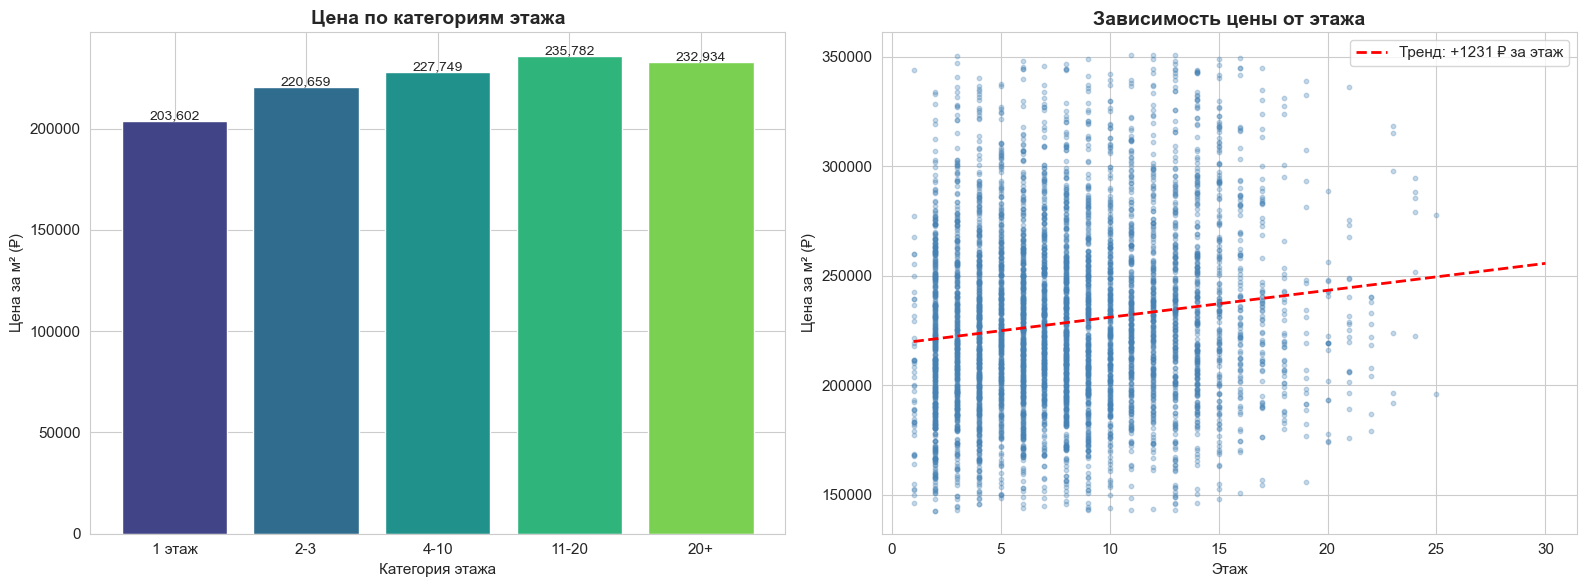

In [20]:
# График 6: Зависимость цены от этажа
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# По категориям этажа
df_model['этаж_категория'] = pd.cut(df_model['этаж_лота'],
                                    bins=[0, 1, 3, 10, 20, 100],
                                    labels=['1 этаж', '2-3', '4-10', '11-20', '20+'])
floor_prices = df_model.groupby('этаж_категория')['цена_за_кв_м'].mean()

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(floor_prices)))
bars = axes[0].bar(floor_prices.index, floor_prices.values, color=colors, edgecolor='white')
for bar, val in zip(bars, floor_prices.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 1000, f'{val:,.0f}', ha='center', fontsize=10)
axes[0].set_xlabel('Категория этажа')
axes[0].set_ylabel('Цена за м² (₽)')
axes[0].set_title('Цена по категориям этажа', fontweight='bold')

# Scatter
axes[1].scatter(sample['этаж_лота'], sample['цена_за_кв_м'], alpha=0.3, s=10, c='steelblue')
df_floor = df_model[['этаж_лота', 'цена_за_кв_м']].dropna()
z = np.polyfit(df_floor['этаж_лота'], df_floor['цена_за_кв_м'], 1)
p = np.poly1d(z)
x_line = np.linspace(1, df_floor['этаж_лота'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Тренд: {z[0]:+.0f} ₽ за этаж')
axes[1].set_xlabel('Этаж')
axes[1].set_ylabel('Цена за м² (₽)')
axes[1].set_title('Зависимость цены от этажа', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('06_price_vs_floor.png', dpi=150, bbox_inches='tight')
plt.show()

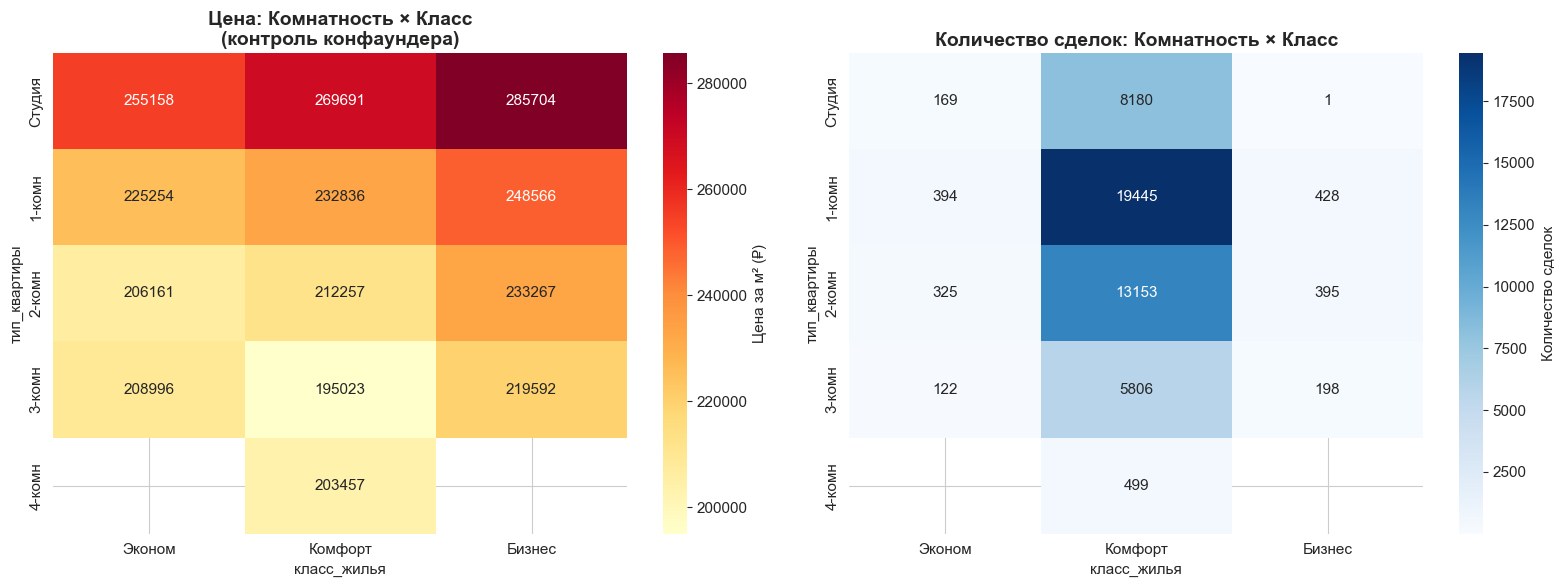


КОНТРОЛЬ КОНФАУНДЕРА: Эффект комнатности внутри каждого класса
Эконом: Студии/1к = 234,231 vs Остальные = 206,934 (+13.2%)
Комфорт: Студии/1к = 243,749 vs Остальные = 206,889 (+17.8%)
Бизнес: Студии/1к = 248,652 vs Остальные = 228,701 (+8.7%)


In [21]:
# График 7: Heatmap - Комнатность × Класс (контроль конфаундера)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot = df_model.pivot_table(values='цена_за_кв_м', index='тип_квартиры', 
                              columns='класс_жилья', aggfunc='mean')
pivot = pivot.reindex([r for r in room_order if r in pivot.index])
pivot = pivot[[c for c in class_order if c in pivot.columns]]

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0],
           cbar_kws={'label': 'Цена за м² (₽)'})
axes[0].set_title('Цена: Комнатность × Класс\n(контроль конфаундера)', fontweight='bold')

# Количество наблюдений
pivot_n = df_model.pivot_table(values='цена_за_кв_м', index='тип_квартиры', 
                                columns='класс_жилья', aggfunc='count')
pivot_n = pivot_n.reindex([r for r in room_order if r in pivot_n.index])
pivot_n = pivot_n[[c for c in class_order if c in pivot_n.columns]]

sns.heatmap(pivot_n, annot=True, fmt='.0f', cmap='Blues', ax=axes[1],
           cbar_kws={'label': 'Количество сделок'})
axes[1].set_title('Количество сделок: Комнатность × Класс', fontweight='bold')

plt.tight_layout()
plt.savefig('07_rooms_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Проверка: сохраняется ли эффект внутри класса?
print("\n" + "="*60)
print("КОНТРОЛЬ КОНФАУНДЕРА: Эффект комнатности внутри каждого класса")
print("="*60)
for cls in class_order:
    if cls in df_model['класс_жилья'].values:
        cls_data = df_model[df_model['класс_жилья'] == cls]
        studio_1k = cls_data[cls_data['малый_формат'] == 1]['цена_за_кв_м'].mean()
        other = cls_data[cls_data['малый_формат'] == 0]['цена_за_кв_м'].mean()
        if not np.isnan(studio_1k) and not np.isnan(other):
            diff = ((studio_1k - other) / other) * 100
            print(f"{cls}: Студии/1к = {studio_1k:,.0f} vs Остальные = {other:,.0f} ({diff:+.1f}%)")

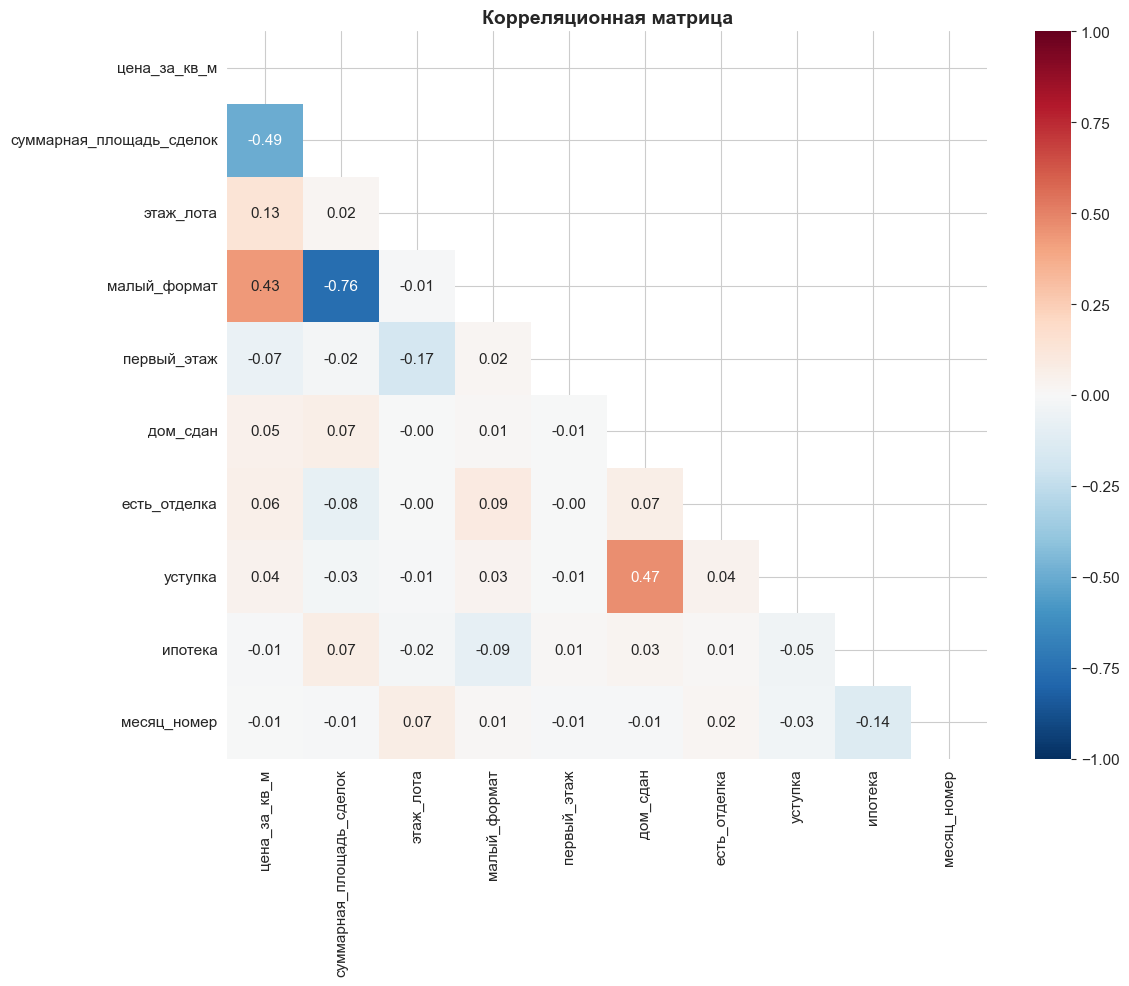

In [22]:
# График 8: Корреляционная матрица
fig, ax = plt.subplots(figsize=(12, 10))

corr_vars = ['цена_за_кв_м', 'суммарная_площадь_сделок', 'этаж_лота', 
             'малый_формат', 'первый_этаж', 'дом_сдан', 'есть_отделка',
             'уступка', 'ипотека', 'месяц_номер']
corr_vars = [v for v in corr_vars if v in df_model.columns]

corr_matrix = df_model[corr_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляционная матрица', fontweight='bold')

plt.tight_layout()
plt.savefig('08_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Подготовка данных для регрессии

### 6.1 Стандартизация числовых признаков (Z-score)

Для сравнимости коэффициентов применяем стандартизацию: **z = (x - μ) / σ**

После стандартизации коэффициент показывает изменение Y при изменении X на 1 стандартное отклонение.

In [23]:
# Числовые признаки для стандартизации
numeric_features = ['суммарная_площадь_сделок', 'этаж_лота', 'относительный_этаж', 'месяц_номер']

# Создаём копию для модели
df_reg = df_model.copy()

# Стандартизация
scaler = StandardScaler()
for col in numeric_features:
    if col in df_reg.columns:
        df_reg[f'{col}_std'] = scaler.fit_transform(df_reg[[col]])
        print(f"{col}: μ={df_reg[col].mean():.2f}, σ={df_reg[col].std():.2f}")

print("\n✓ Стандартизация выполнена")

суммарная_площадь_сделок: μ=46.72, σ=19.29
этаж_лота: μ=8.04, σ=4.46
относительный_этаж: μ=0.52, σ=0.26
месяц_номер: μ=12.74, σ=6.23

✓ Стандартизация выполнена


In [24]:
# Создание dummy-переменных для категориальных признаков
# Выбор базовых категорий:
# - Тип квартиры: 2-комн (средний формат, для сравнения)
# - Класс: Комфорт (наиболее частый)
# - Район: Коммунарка (наиболее частый)
# - Стадия: Строительство (наиболее частый)
# - Отделка: Без отделки (базовый вариант)

print("Базовые категории (reference):")
print("  Тип квартиры: 2-комн")
print("  Класс: Комфорт")
print("  Район: Коммунарка") 
print("  Стадия: Строительство")
print("  Застройщик: Самолет")

Базовые категории (reference):
  Тип квартиры: 2-комн
  Класс: Комфорт
  Район: Коммунарка
  Стадия: Строительство
  Застройщик: Самолет


---
## 7. Построение модели линейной регрессии (OLS)

In [25]:
# Формула модели
# Используем стандартизированные числовые признаки и категориальные через C()

formula = """
цена_за_кв_м ~ 
    суммарная_площадь_сделок_std + 
    этаж_лота_std + 
    первый_этаж + 
    последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка +
    уступка + 
    ипотека +
    месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""

print("Формула модели:")
print(formula)

Формула модели:

цена_за_кв_м ~ 
    суммарная_площадь_сделок_std + 
    этаж_лота_std + 
    первый_этаж + 
    последний_этаж +
    C(тип_квартиры, Treatment(reference='2-комн')) + 
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка +
    уступка + 
    ипотека +
    месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))



In [26]:
# Оценка модели OLS
model = smf.ols(formula, data=df_reg).fit()

print("="*80)
print("РЕЗУЛЬТАТЫ МОДЕЛИ OLS (стандартные ошибки)")
print("="*80)
print(model.summary())

РЕЗУЛЬТАТЫ МОДЕЛИ OLS (стандартные ошибки)
                            OLS Regression Results                            
Dep. Variable:           цена_за_кв_м   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     3489.
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:19:44   Log-Likelihood:            -5.6573e+05
No. Observations:               49115   AIC:                         1.132e+06
Df Residuals:                   49088   BIC:                         1.132e+06
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                                                coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

---
## 8. Диагностика модели

In [27]:
# 8.1 Проверка мультиколлинеарности (VIF)
print("="*60)
print("8.1 МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)")
print("="*60)
print("Критерии: VIF < 5 — норма, VIF 5-10 — предупреждение, VIF > 10 — проблема\n")

# Получаем матрицу признаков
X = model.model.exog
feature_names = model.model.exog_names

vif_data = []
for i in range(X.shape[1]):
    vif = variance_inflation_factor(X, i)
    vif_data.append({'Признак': feature_names[i], 'VIF': vif})

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)
vif_df['Статус'] = vif_df['VIF'].apply(lambda x: '✓ OK' if x < 5 else ('⚠ Внимание' if x < 10 else '❌ Проблема'))
print(vif_df.to_string(index=False))

max_vif = vif_df['VIF'].max()
if max_vif > 10:
    print(f"\n⚠️ Обнаружена мультиколлинеарность (max VIF = {max_vif:.1f})")
else:
    print(f"\n✓ Мультиколлинеарность в норме (max VIF = {max_vif:.1f})")

8.1 МУЛЬТИКОЛЛИНЕАРНОСТЬ (VIF)
Критерии: VIF < 5 — норма, VIF 5-10 — предупреждение, VIF > 10 — проблема

                                                                  Признак       VIF     Статус
                                                                Intercept 19.945732 ❌ Проблема
                                             суммарная_площадь_сделок_std  4.459178       ✓ OK
                C(застройщик_топ, Treatment(reference='Самолет'))[T.РОСТ]  3.576212       ✓ OK
                 C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]  3.174160       ✓ OK
                C(застройщик_топ, Treatment(reference='Самолет'))[T.А101]  2.798909       ✓ OK
                    C(район, Treatment(reference='Коммунарка'))[T.Троицк]  2.603586       ✓ OK
                 C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]  2.541699       ✓ OK
                   C(район, Treatment(reference='Коммунарка'))[T.Внуково]  1.874162       ✓ OK
                  C(район, Treatment(re

In [28]:
# 8.2 Тест на гетероскедастичность (Breusch-Pagan)
print("="*60)
print("8.2 ГЕТЕРОСКЕДАСТИЧНОСТЬ (Breusch-Pagan test)")
print("="*60)
print("H0: Гомоскедастичность (дисперсия ошибок постоянна)")
print("H1: Гетероскедастичность (дисперсия ошибок зависит от предикторов)\n")

bp_stat, bp_pvalue, _, _ = het_breuschpagan(model.resid, model.model.exog)
print(f"Статистика BP: {bp_stat:.2f}")
print(f"p-value: {bp_pvalue:.2e}")

if bp_pvalue < 0.05:
    print("\n❌ Гетероскедастичность ОБНАРУЖЕНА (p < 0.05)")
    print("   → Необходимо использовать робастные стандартные ошибки (HC3)")
    heteroscedasticity_detected = True
else:
    print("\n✓ Гомоскедастичность подтверждена (p >= 0.05)")
    heteroscedasticity_detected = False

8.2 ГЕТЕРОСКЕДАСТИЧНОСТЬ (Breusch-Pagan test)
H0: Гомоскедастичность (дисперсия ошибок постоянна)
H1: Гетероскедастичность (дисперсия ошибок зависит от предикторов)

Статистика BP: 5901.76
p-value: 0.00e+00

❌ Гетероскедастичность ОБНАРУЖЕНА (p < 0.05)
   → Необходимо использовать робастные стандартные ошибки (HC3)


In [29]:
# 8.3 Тест на нормальность остатков
print("="*60)
print("8.3 НОРМАЛЬНОСТЬ ОСТАТКОВ")
print("="*60)

residuals = model.resid

# Jarque-Bera test (лучше для больших выборок)
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)
print(f"\nJarque-Bera test:")
print(f"  Статистика: {jb_stat:.2f}")
print(f"  p-value: {jb_pvalue:.2e}")
print(f"  Асимметрия (skewness): {skew:.3f} (норма ≈ 0)")
print(f"  Эксцесс (kurtosis): {kurtosis:.3f} (норма ≈ 3)")

# Shapiro-Wilk test (на подвыборке, т.к. ограничен 5000 наблюдениями)
sample_resid = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
sw_stat, sw_pvalue = shapiro(sample_resid)
print(f"\nShapiro-Wilk test (на выборке n={len(sample_resid)}):")
print(f"  Статистика: {sw_stat:.4f}")
print(f"  p-value: {sw_pvalue:.2e}")

if jb_pvalue < 0.05:
    print("\n⚠️ Остатки НЕ нормально распределены (p < 0.05)")
    print("   Это типично для больших выборок. При n > 1000 OLS устойчив благодаря ЦПТ.")
    normality_violated = True
else:
    print("\n✓ Нормальность остатков подтверждена")
    normality_violated = False

8.3 НОРМАЛЬНОСТЬ ОСТАТКОВ

Jarque-Bera test:
  Статистика: 3651.85
  p-value: 0.00e+00
  Асимметрия (skewness): 0.345 (норма ≈ 0)
  Эксцесс (kurtosis): 4.144 (норма ≈ 3)

Shapiro-Wilk test (на выборке n=5000):
  Статистика: 0.9910
  p-value: 2.91e-17

⚠️ Остатки НЕ нормально распределены (p < 0.05)
   Это типично для больших выборок. При n > 1000 OLS устойчив благодаря ЦПТ.


In [30]:
# 8.4 Автокорреляция остатков (Durbin-Watson)
print("="*60)
print("8.4 АВТОКОРРЕЛЯЦИЯ ОСТАТКОВ (Durbin-Watson)")
print("="*60)
print("Интерпретация: DW ≈ 2 — нет автокорреляции")
print("              DW < 1.5 — положительная автокорреляция")
print("              DW > 2.5 — отрицательная автокорреляция\n")

dw_stat = durbin_watson(residuals)
print(f"Durbin-Watson: {dw_stat:.3f}")

if 1.5 <= dw_stat <= 2.5:
    print("\n✓ Автокорреляция не обнаружена")
else:
    print("\n⚠️ Возможна автокорреляция остатков")

8.4 АВТОКОРРЕЛЯЦИЯ ОСТАТКОВ (Durbin-Watson)
Интерпретация: DW ≈ 2 — нет автокорреляции
              DW < 1.5 — положительная автокорреляция
              DW > 2.5 — отрицательная автокорреляция

Durbin-Watson: 0.672

⚠️ Возможна автокорреляция остатков


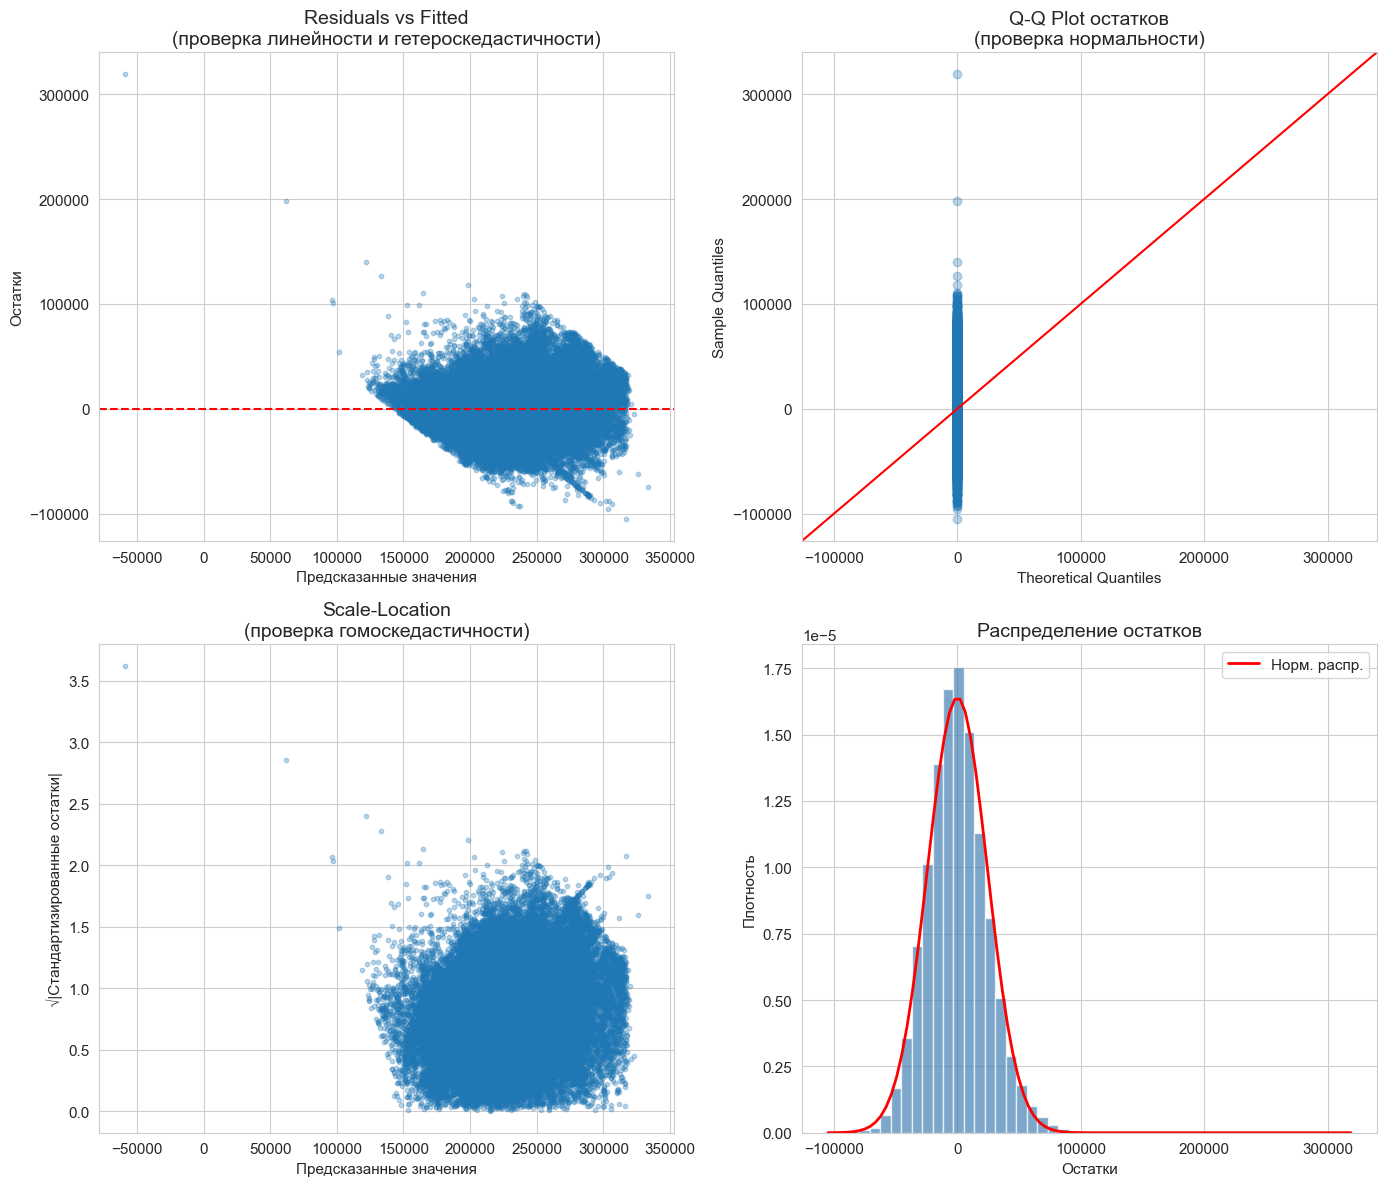

✓ Сохранено: 09_residual_diagnostics.png


In [31]:
# 8.5 Графическая диагностика
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Residuals vs Fitted
fitted = model.fittedvalues
axes[0, 0].scatter(fitted, residuals, alpha=0.3, s=10)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Предсказанные значения')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].set_title('Residuals vs Fitted\n(проверка линейности и гетероскедастичности)')

# 2. Q-Q Plot
qqplot(residuals, line='45', ax=axes[0, 1], alpha=0.3)
axes[0, 1].set_title('Q-Q Plot остатков\n(проверка нормальности)')

# 3. Scale-Location (sqrt of standardized residuals vs fitted)
standardized_resid = (residuals - residuals.mean()) / residuals.std()
axes[1, 0].scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.3, s=10)
axes[1, 0].set_xlabel('Предсказанные значения')
axes[1, 0].set_ylabel('√|Стандартизированные остатки|')
axes[1, 0].set_title('Scale-Location\n(проверка гомоскедастичности)')

# 4. Гистограмма остатков
axes[1, 1].hist(residuals, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
# Наложим нормальное распределение
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[1, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', linewidth=2, label='Норм. распр.')
axes[1, 1].set_xlabel('Остатки')
axes[1, 1].set_ylabel('Плотность')
axes[1, 1].set_title('Распределение остатков')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('09_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Сохранено: 09_residual_diagnostics.png")

8.6 ВЛИЯТЕЛЬНЫЕ НАБЛЮДЕНИЯ (Cook's Distance)
Порог Cook's D: 0.000081 (4/n)
Влиятельных наблюдений: 2097 (4.27%)


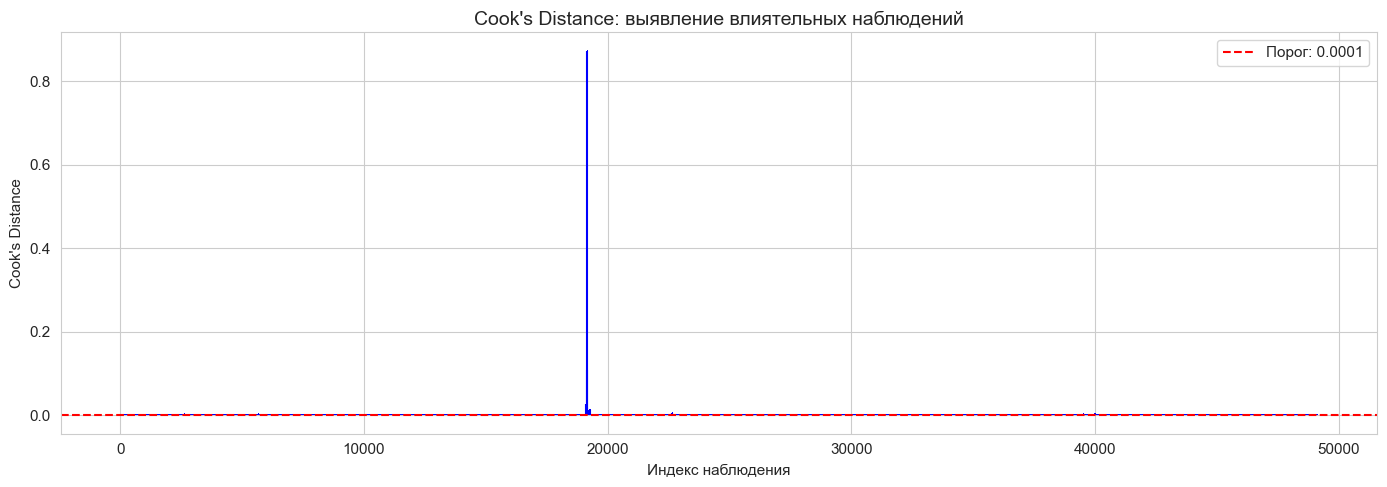

In [32]:
# 8.6 Влиятельные наблюдения (Cook's Distance)
print("="*60)
print("8.6 ВЛИЯТЕЛЬНЫЕ НАБЛЮДЕНИЯ (Cook's Distance)")
print("="*60)

influence = OLSInfluence(model)
cooks_d = influence.cooks_distance[0]

# Порог: 4/n
threshold = 4 / len(df_reg)
n_influential = (cooks_d > threshold).sum()

print(f"Порог Cook's D: {threshold:.6f} (4/n)")
print(f"Влиятельных наблюдений: {n_influential} ({n_influential/len(df_reg)*100:.2f}%)")

# График
fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',', linefmt='b-', basefmt=' ')
ax.axhline(y=threshold, color='red', linestyle='--', label=f'Порог: {threshold:.4f}')
ax.set_xlabel('Индекс наблюдения')
ax.set_ylabel("Cook's Distance")
ax.set_title("Cook's Distance: выявление влиятельных наблюдений")
ax.legend()

plt.tight_layout()
plt.savefig('10_cooks_distance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Исправление проблем: Робастные стандартные ошибки

In [33]:
# При обнаружении гетероскедастичности используем HC3 робастные ошибки
print("="*80)
print("МОДЕЛЬ С РОБАСТНЫМИ СТАНДАРТНЫМИ ОШИБКАМИ (HC3)")
print("="*80)
print("\nHC3 корректирует стандартные ошибки при наличии гетероскедастичности.")
print("Коэффициенты остаются теми же, но p-value могут измениться.\n")

# Робастная модель
model_robust = model.get_robustcov_results(cov_type='HC3')
print(model_robust.summary())

МОДЕЛЬ С РОБАСТНЫМИ СТАНДАРТНЫМИ ОШИБКАМИ (HC3)

HC3 корректирует стандартные ошибки при наличии гетероскедастичности.
Коэффициенты остаются теми же, но p-value могут измениться.

                            OLS Regression Results                            
Dep. Variable:           цена_за_кв_м   R-squared:                       0.649
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     3742.
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        17:19:48   Log-Likelihood:            -5.6573e+05
No. Observations:               49115   AIC:                         1.132e+06
Df Residuals:                   49088   BIC:                         1.132e+06
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                              

---
## 10. Анализ и интерпретация коэффициентов

In [34]:
# Извлекаем результаты из робастной модели
results_df = pd.DataFrame({
    'Коэффициент': model_robust.params,
    'Станд. ошибка': model_robust.bse,
    't-статистика': model_robust.tvalues,
    'p-value': model_robust.pvalues,
    'CI_low': model_robust.conf_int()[0],
    'CI_high': model_robust.conf_int()[1]
})

# Добавляем интерпретацию значимости
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

results_df['Значимость'] = results_df['p-value'].apply(significance_stars)

# Сортируем по абсолютному значению коэффициента
results_df['|Коэф.|'] = results_df['Коэффициент'].abs()
results_df_sorted = results_df.sort_values('|Коэф.|', ascending=False)

print("="*100)
print("КОЭФФИЦИЕНТЫ МОДЕЛИ (отсортированы по силе влияния)")
print("="*100)
print("\nЗначимость: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")
print("\nИнтерпретация стандартизированных коэффициентов:")
print("  Коэффициент показывает изменение цены за м² (₽) при изменении признака на 1 SD\n")

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(results_df_sorted[['Коэффициент', 'Станд. ошибка', 't-статистика', 'p-value', 'Значимость']].to_string())

ValueError: All arrays must be of the same length

In [ ]:
# Визуализация коэффициентов
fig, ax = plt.subplots(figsize=(12, 10))

# Исключаем Intercept для наглядности
coef_plot = results_df_sorted[results_df_sorted.index != 'Intercept'].copy()

# Цвета: значимые — синий/красный, незначимые — серый
colors = []
for idx, row in coef_plot.iterrows():
    if row['p-value'] >= 0.05:
        colors.append('gray')
    elif row['Коэффициент'] > 0:
        colors.append('green')
    else:
        colors.append('red')

y_pos = range(len(coef_plot))
ax.barh(y_pos, coef_plot['Коэффициент'], color=colors, edgecolor='white', alpha=0.8)
ax.errorbar(coef_plot['Коэффициент'], y_pos, 
           xerr=[coef_plot['Коэффициент'] - coef_plot['CI_low'], 
                 coef_plot['CI_high'] - coef_plot['Коэффициент']],
           fmt='none', color='black', capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(coef_plot.index)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Коэффициент (изменение цены за м² в ₽)')
ax.set_title('Коэффициенты регрессии с 95% доверительными интервалами\n(зелёный = положительный, красный = отрицательный, серый = незначимый)', 
            fontweight='bold')

plt.tight_layout()
plt.savefig('11_coefficients_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Детальная интерпретация каждого коэффициента
print("="*100)
print("ДЕТАЛЬНАЯ ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ")
print("="*100)

interpretations = {
    'Intercept': {
        'description': 'Базовая цена за м² для 2-комнатной квартиры класса Комфорт в Коммунарке на этапе строительства',
        'expected': 'Положительный (базовый уровень цены)'
    },
    'суммарная_площадь_сделок_std': {
        'description': 'Изменение цены при увеличении площади на 1 SD',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ (эффект масштаба: больше площадь → ниже цена за м²)'
    },
    'этаж_лота_std': {
        'description': 'Изменение цены при увеличении этажа на 1 SD',
        'expected': 'Положительный (выше этаж → лучше вид, тише)'
    },
    'первый_этаж': {
        'description': 'Дисконт первого этажа относительно остальных',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ (шум, безопасность, отсутствие вида)'
    },
    'последний_этаж': {
        'description': 'Премия/дисконт последнего этажа',
        'expected': 'Неоднозначный (в новостройках часто премия за вид, в старом фонде — дисконт)'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]": {
        'description': 'Премия студии относительно 2-комнатной',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ (инвестиционная привлекательность, низкий порог входа)'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]": {
        'description': 'Премия 1-комнатной относительно 2-комнатной',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ (высокая ликвидность, спрос инвесторов)'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.3-комн]": {
        'description': 'Дисконт 3-комнатной относительно 2-комнатной',
        'expected': 'Отрицательный (ниже ликвидность, дольше продаётся)'
    },
    "C(тип_квартиры, Treatment(reference='2-комн'))[T.4-комн]": {
        'description': 'Дисконт 4-комнатной относительно 2-комнатной',
        'expected': 'Отрицательный (узкий спрос, низкая ликвидность)'
    },
    "C(класс_жилья, Treatment(reference='Комфорт'))[T.Эконом]": {
        'description': 'Дисконт эконом-класса относительно комфорта',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ (ниже качество, локация)'
    },
    "C(класс_жилья, Treatment(reference='Комфорт'))[T.Бизнес]": {
        'description': 'Премия бизнес-класса относительно комфорта',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ (выше качество, локация, отделка)'
    },
    "C(стадия, Treatment(reference='Строительство'))[T.Котлован]": {
        'description': 'Дисконт покупки на котловане',
        'expected': 'ОТРИЦАТЕЛЬНЫЙ (выше риск, дольше ждать)'
    },
    "C(стадия, Treatment(reference='Строительство'))[T.Сдан]": {
        'description': 'Премия готового дома',
        'expected': 'ПОЛОЖИТЕЛЬНЫЙ (нет риска, можно заехать)'
    },
    'есть_отделка': {
        'description': 'Премия квартиры с отделкой',
        'expected': 'Положительный (экономия времени и денег покупателя)'
    },
    'уступка': {
        'description': 'Разница цены при покупке по договору уступки',
        'expected': 'Неоднозначный (теоретически +5-15% маржа инвестора, но зависит от ситуации)'
    },
    'ипотека': {
        'description': 'Разница цены при ипотечной сделке',
        'expected': 'Слабый/нулевой (ипотека — способ оплаты, не характеристика квартиры)'
    },
    'месяц_номер_std': {
        'description': 'Временной тренд (изменение цены со временем)',
        'expected': 'Зависит от рынка (рост/падение/стагнация)'
    }
}

for var_name, info in interpretations.items():
    if var_name in results_df.index:
        row = results_df.loc[var_name]
        coef = row['Коэффициент']
        pval = row['p-value']
        sig = row['Значимость']
        
        print(f"\n{'─'*80}")
        print(f"📊 {var_name}")
        print(f"{'─'*80}")
        print(f"   Описание: {info['description']}")
        print(f"   Ожидаемый знак: {info['expected']}")
        print(f"   Коэффициент: {coef:+,.2f} ₽/м²")
        print(f"   p-value: {pval:.4f} {sig}")
        
        # Проверка соответствия ожиданиям
        if pval < 0.05:
            print(f"   ✅ Статистически ЗНАЧИМ (p < 0.05)")
        else:
            print(f"   ⚪ Статистически НЕ значим (p >= 0.05)")

---
## 11. Проверка гипотезы: Студии и 1к дороже за м²

In [35]:
print("="*80)
print("🎯 ПРОВЕРКА ГИПОТЕЗЫ: Студии и однокомнатные квартиры дороже за м²")
print("="*80)

# Извлекаем коэффициенты для типов квартир
studio_var = "C(тип_квартиры, Treatment(reference='2-комн'))[T.Студия]"
oneroom_var = "C(тип_квартиры, Treatment(reference='2-комн'))[T.1-комн]"

print("\n" + "-"*60)
print("H0: Студии и 1к НЕ отличаются по цене от 2к (коэффициент = 0)")
print("H1: Студии и 1к ДОРОЖЕ за м², чем 2к (коэффициент > 0)")
print("-"*60)

for var_name, var_label in [(studio_var, 'СТУДИЯ'), (oneroom_var, '1-КОМНАТНАЯ')]:
    if var_name in results_df.index:
        row = results_df.loc[var_name]
        coef = row['Коэффициент']
        pval = row['p-value']
        ci_low = row['CI_low']
        ci_high = row['CI_high']
        
        print(f"\n📌 {var_label} vs 2-комнатная:")
        print(f"   Коэффициент: {coef:+,.2f} ₽/м²")
        print(f"   95% ДИ: [{ci_low:+,.2f}; {ci_high:+,.2f}]")
        print(f"   p-value: {pval:.2e}")
        
        if pval < 0.05 and coef > 0:
            print(f"   ✅ ГИПОТЕЗА ПОДТВЕРЖДЕНА: {var_label} дороже на {coef:,.0f} ₽/м² (p < 0.05)")
        elif pval < 0.05 and coef < 0:
            print(f"   ❌ ГИПОТЕЗА ОТВЕРГНУТА: {var_label} ДЕШЕВЛЕ на {abs(coef):,.0f} ₽/м²")
        else:
            print(f"   ⚪ Статистически значимых различий не обнаружено (p >= 0.05)")

🎯 ПРОВЕРКА ГИПОТЕЗЫ: Студии и однокомнатные квартиры дороже за м²

------------------------------------------------------------
H0: Студии и 1к НЕ отличаются по цене от 2к (коэффициент = 0)
H1: Студии и 1к ДОРОЖЕ за м², чем 2к (коэффициент > 0)
------------------------------------------------------------


NameError: name 'results_df' is not defined

In [ ]:
# F-тест: совместная значимость типа квартиры
print("\n" + "="*60)
print("F-ТЕСТ: Влияет ли тип квартиры на цену в целом?")
print("="*60)

# Строим ограниченную модель без типа квартиры
formula_restricted = """
цена_за_кв_м ~ 
    суммарная_площадь_сделок_std + 
    этаж_лота_std + 
    первый_этаж + 
    последний_этаж +
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка +
    уступка + 
    ипотека +
    месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""

model_restricted = smf.ols(formula_restricted, data=df_reg).fit()

# F-тест сравнения моделей
from scipy.stats import f as f_dist

ssr_full = model.ssr  # Sum of squared residuals полной модели
ssr_restricted = model_restricted.ssr  # SSR ограниченной модели
df_diff = model_restricted.df_resid - model.df_resid  # Разница в степенях свободы
df_full = model.df_resid

f_stat = ((ssr_restricted - ssr_full) / df_diff) / (ssr_full / df_full)
f_pvalue = 1 - f_dist.cdf(f_stat, df_diff, df_full)

print(f"\nH0: Тип квартиры НЕ влияет на цену (все коэффициенты = 0)")
print(f"H1: Тип квартиры ВЛИЯЕТ на цену (хотя бы один коэффициент ≠ 0)")
print(f"\nF-статистика: {f_stat:.2f}")
print(f"p-value: {f_pvalue:.2e}")

if f_pvalue < 0.05:
    print(f"\n✅ Тип квартиры СТАТИСТИЧЕСКИ ЗНАЧИМО влияет на цену за м² (p < 0.05)")
else:
    print(f"\n⚪ Тип квартиры не оказывает значимого влияния на цену")

In [ ]:
# Дополнительная проверка: тест малого формата (студия + 1к) vs остальных
print("\n" + "="*60)
print("АЛЬТЕРНАТИВНАЯ ПРОВЕРКА: Малый формат (студия + 1к) vs Остальные")
print("="*60)

formula_binary = """
цена_за_кв_м ~ 
    суммарная_площадь_сделок_std + 
    этаж_лота_std + 
    первый_этаж + 
    последний_этаж +
    малый_формат +
    C(класс_жилья, Treatment(reference='Комфорт')) + 
    C(район, Treatment(reference='Коммунарка')) + 
    C(стадия, Treatment(reference='Строительство')) +
    есть_отделка +
    уступка + 
    ипотека +
    месяц_номер_std +
    C(застройщик_топ, Treatment(reference='Самолет'))
"""

model_binary = smf.ols(formula_binary, data=df_reg).fit(cov_type='HC3')

coef_small = model_binary.params['малый_формат']
pval_small = model_binary.pvalues['малый_формат']
ci_small = model_binary.conf_int().loc['малый_формат']

print(f"\nМалый формат (студия + 1к) относительно остальных (2к, 3к, 4к):")
print(f"   Коэффициент: {coef_small:+,.2f} ₽/м²")
print(f"   95% ДИ: [{ci_small[0]:+,.2f}; {ci_small[1]:+,.2f}]")
print(f"   p-value: {pval_small:.2e}")

if pval_small < 0.05 and coef_small > 0:
    print(f"\n✅ ГИПОТЕЗА ПОДТВЕРЖДЕНА:")
    print(f"   Студии и 1к дороже за м² в среднем на {coef_small:,.0f} ₽")
    print(f"   при прочих равных условиях (контроль класса, района, площади и т.д.)")

---
## 12. Итоговые метрики качества модели

In [36]:
print("="*80)
print("📊 ИТОГОВЫЕ МЕТРИКИ КАЧЕСТВА МОДЕЛИ")
print("="*80)

print(f"""
┌────────────────────────────────────────────────────────────┐
│ МЕТРИКИ КАЧЕСТВА                                           │
├────────────────────────────────────────────────────────────┤
│ R² (коэф. детерминации):     {model_robust.rsquared:.4f}                       │
│ Adjusted R²:                 {model_robust.rsquared_adj:.4f}                       │
│ F-статистика:                {model_robust.fvalue:.2f}                        │
│ p-value (F-тест):            {model_robust.f_pvalue:.2e}                     │
│ AIC:                         {model_robust.aic:,.0f}                       │
│ BIC:                         {model_robust.bic:,.0f}                       │
│ Число наблюдений:            {model_robust.nobs:,.0f}                          │
│ Число параметров:            {len(model_robust.params)}                               │
└────────────────────────────────────────────────────────────┘
""")

print("\nИНТЕРПРЕТАЦИЯ:")
print(f"  • Модель объясняет {model_robust.rsquared*100:.1f}% вариации цены за м²")
print(f"  • F-тест значим (p < 0.001): модель в целом работает лучше, чем просто среднее")
print(f"  • Adjusted R² учитывает штраф за количество переменных")

📊 ИТОГОВЫЕ МЕТРИКИ КАЧЕСТВА МОДЕЛИ

┌────────────────────────────────────────────────────────────┐
│ МЕТРИКИ КАЧЕСТВА                                           │
├────────────────────────────────────────────────────────────┤
│ R² (коэф. детерминации):     0.6489                       │
│ Adjusted R²:                 0.6487                       │
│ F-статистика:                3741.97                        │
│ p-value (F-тест):            0.00e+00                     │
│ AIC:                         1,131,506                       │
│ BIC:                         1,131,744                       │
│ Число наблюдений:            49,115                          │
│ Число параметров:            27                               │
└────────────────────────────────────────────────────────────┘


ИНТЕРПРЕТАЦИЯ:
  • Модель объясняет 64.9% вариации цены за м²
  • F-тест значим (p < 0.001): модель в целом работает лучше, чем просто среднее
  • Adjusted R² учитывает штраф за количество переменных

In [ ]:
# Предсказательная способность: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(df_reg['цена_за_кв_м'], model.fittedvalues, alpha=0.3, s=10)
axes[0].plot([df_reg['цена_за_кв_м'].min(), df_reg['цена_за_кв_м'].max()],
            [df_reg['цена_за_кв_м'].min(), df_reg['цена_за_кв_м'].max()], 
            'r--', linewidth=2, label='Идеальное предсказание')
axes[0].set_xlabel('Фактическая цена за м² (₽)')
axes[0].set_ylabel('Предсказанная цена за м² (₽)')
axes[0].set_title(f'Actual vs Predicted (R² = {model.rsquared:.3f})', fontweight='bold')
axes[0].legend()

# Распределение ошибок предсказания
errors = df_reg['цена_за_кв_м'] - model.fittedvalues
mape = np.mean(np.abs(errors) / df_reg['цена_за_кв_м']) * 100
rmse = np.sqrt(np.mean(errors**2))

axes[1].hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_xlabel('Ошибка предсказания (₽)')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок\nRMSE = {rmse:,.0f} ₽, MAPE = {mape:.1f}%', fontweight='bold')

plt.tight_layout()
plt.savefig('12_prediction_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nМетрики точности предсказания:")
print(f"  RMSE: {rmse:,.0f} ₽ (среднеквадратичная ошибка)")
print(f"  MAPE: {mape:.1f}% (средняя абсолютная процентная ошибка)")

---
## 13. Выводы

In [37]:
print("="*80)
print("📋 ИТОГОВЫЕ ВЫВОДЫ")
print("="*80)

# Собираем ключевые результаты
studio_coef = results_df.loc[studio_var, 'Коэффициент'] if studio_var in results_df.index else 0
oneroom_coef = results_df.loc[oneroom_var, 'Коэффициент'] if oneroom_var in results_df.index else 0
studio_pval = results_df.loc[studio_var, 'p-value'] if studio_var in results_df.index else 1
oneroom_pval = results_df.loc[oneroom_var, 'p-value'] if oneroom_var in results_df.index else 1

print(f"""
┌─────────────────────────────────────────────────────────────────────────────────┐
│ 1. ГЛАВНАЯ ГИПОТЕЗА: Студии и 1к дороже за м²                                   │
├─────────────────────────────────────────────────────────────────────────────────┤
│                                                                                 │
│   СТУДИЯ vs 2-комнатная:                                                        │
│     Премия: {studio_coef:+,.0f} ₽/м²                                                      │
│     p-value: {studio_pval:.2e}                                                          │
│     Результат: {'✅ ПОДТВЕРЖДЕНО' if studio_pval < 0.05 and studio_coef > 0 else '❌ НЕ подтверждено'}                                                       │
│                                                                                 │
│   1-КОМНАТНАЯ vs 2-комнатная:                                                   │
│     Премия: {oneroom_coef:+,.0f} ₽/м²                                                      │
│     p-value: {oneroom_pval:.2e}                                                          │
│     Результат: {'✅ ПОДТВЕРЖДЕНО' if oneroom_pval < 0.05 and oneroom_coef > 0 else '❌ НЕ подтверждено'}                                                       │
│                                                                                 │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 2. КАЧЕСТВО МОДЕЛИ                                                              │
├─────────────────────────────────────────────────────────────────────────────────┤
│   R² = {model_robust.rsquared:.3f} (модель объясняет {model_robust.rsquared*100:.1f}% вариации)                           │
│   RMSE = {rmse:,.0f} ₽                                                                 │
│   MAPE = {mape:.1f}%                                                                    │
│                                                                                 │
├─────────────────────────────────────────────────────────────────────────────────┤
│ 3. ДИАГНОСТИКА                                                                  │
├─────────────────────────────────────────────────────────────────────────────────┤
│   Мультиколлинеарность: {'✓ В норме' if max_vif < 10 else '⚠ Обнаружена'}                                              │
│   Гетероскедастичность: {'⚠ Обнаружена → использованы HC3 робастные ошибки' if heteroscedasticity_detected else '✓ В норме'}│
│   Нормальность остатков: {'⚠ Отклонения (типично для больших выборок)' if normality_violated else '✓ В норме'}         │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*80)
print("ЭКОНОМИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ")
print("="*80)
print("""
Почему студии и однокомнатные квартиры дороже за м²?

1. ИНВЕСТИЦИОННАЯ ПРИВЛЕКАТЕЛЬНОСТЬ
   • Доходность аренды студий: 5-8% годовых vs 3-5% для 2к+
   • Быстрее сдаются в аренду (высокий спрос)
   • Легче продать (выше ликвидность)

2. НИЗКИЙ ПОРОГ ВХОДА
   • Меньший бюджет → доступно большему числу покупателей
   • Высокий спрос → рост цены за м²

3. СТРУКТУРА СЕБЕСТОИМОСТИ
   • Фиксированные издержки (кухня, санузел, коммуникации) 
     распределяются на меньшую площадь → выше себестоимость за м²

4. ДЕФИЦИТ ПРЕДЛОЖЕНИЯ
   • Застройщики отдают предпочтение семейным форматам
   • Студий и 1к в продаже меньше → выше цена

Источники: ЦИАН, Домклик, IRN, hedonic pricing literature (Rosen 1974)
""")

📋 ИТОГОВЫЕ ВЫВОДЫ


NameError: name 'results_df' is not defined

In [ ]:
# Сохранение результатов
results_df.to_csv('regression_coefficients.csv')
df_reg.to_csv('enriched_data_for_model.csv', index=False)

print("\n📁 Сохранённые файлы:")
print("  • regression_coefficients.csv — коэффициенты модели")
print("  • enriched_data_for_model.csv — данные с признаками")
print("  • 01-12_*.png — графики")

print("\n" + "="*80)
print("✅ АНАЛИЗ ЗАВЕРШЁН")
print("="*80)